# 🏙️ PropertyIQ: A 20-Minute Data Visualization Sprint
### Unit 1 — Foundations of Visualization, Data Interpretation (UE24CS342AA9)

**Dataset:** [Melbourne Housing Snapshot](https://www.kaggle.com/datasets/dansbecker/melbourne-housing-snapshot) (Kaggle)

---

## 📖 The Scenario

You have just joined **PropertyIQ**, a Melbourne-based real-estate analytics startup, as a **junior data analyst**.

Tomorrow morning, your **Head of Sales** is meeting a client — a property investment fund — and needs a short briefing built from the `melb_data.csv` housing snapshot. She has given you **20 minutes** to turn the raw data into something she can actually present.

She says:

> *"I don't want a data dump. I want to walk in, show three good visuals, and leave the client with one clear takeaway. Make sure the charts are the right *type*, saved in the right *format*, and that the design doesn't get in the way of the message."*

This activity walks you through exactly the workflow described in the lecture: **understand the context → choose the right chart → choose the right file format → separate content from design → tell the story.**




## Part 0 — Setup (1 min)

1. Download **`melb_data.csv`** from the [Kaggle dataset page](https://www.kaggle.com/datasets/dansbecker/melbourne-housing-snapshot).
2. Place it in the **same folder** as this notebook.
3. Run the cell below.

*(If the file isn't found, the cell will auto-generate a small synthetic stand-in with the same columns, so you can still complete the activity — just swap in the real CSV later.)*


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

np.random.seed(42)

DATA_PATH = "melb_data.csv"

if os.path.exists(DATA_PATH):
    df = pd.read_csv("D:\\VDUI_HANDSON\\unit1\\ppt9\\melb_data.csv")
    print(f"Loaded real dataset: {df.shape[0]} rows, {df.shape[1]} columns")
else:
    print("melb_data.csv not found — generating a small synthetic stand-in so you can still run the activity.")
    n = 600
    regions = ["Northern Metropolitan", "Western Metropolitan", "Southern Metropolitan",
               "Eastern Metropolitan", "South-Eastern Metropolitan"]
    types = ["h", "u", "t"]  # house, unit, townhouse
    df = pd.DataFrame({
        "Suburb": np.random.choice(["Richmond", "Brunswick", "Carlton", "Footscray",
                                     "St Kilda", "Fitzroy", "Camberwell"], n),
        "Rooms": np.random.randint(1, 6, n),
        "Type": np.random.choice(types, n, p=[0.6, 0.3, 0.1]),
        "Price": np.random.lognormal(mean=13.5, sigma=0.4, size=n).round(-3),
        "Distance": np.round(np.random.exponential(8, n), 1),
        "Landsize": np.random.exponential(400, n).round(0),
        "BuildingArea": np.random.normal(150, 50, n).clip(30, 500).round(0),
        "YearBuilt": np.random.randint(1900, 2018, n),
        "Regionname": np.random.choice(regions, n),
        "Bathroom": np.random.randint(1, 4, n),
        "Car": np.random.randint(0, 4, n),
    })

df.head()


Loaded real dataset: 18396 rows, 22 columns


,Unnamed: 0,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,5,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,6,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


## Part 1 — Understand the Context (3 min)

> *"Good data visualization begins with understanding the problem, not by choosing a chart."*

Recall the lecture's distinction:

| Exploratory Analysis | Explanatory Analysis |
|---|---|
| Explores data to discover patterns | Communicates a clear insight |
| Multiple hypotheses tested | One key message emphasized |
| Used by the analyst | Designed for the audience |

**Run the cell below** to get a quick feel for the data (this is *exploratory* — you're doing it for yourself, not the client).


In [3]:
df.info()
df.describe(include="all").T.head(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18396 entries, 0 to 18395
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     18396 non-null  int64  
 1   Suburb         18396 non-null  object 
 2   Address        18396 non-null  object 
 3   Rooms          18396 non-null  int64  
 4   Type           18396 non-null  object 
 5   Price          18396 non-null  float64
 6   Method         18396 non-null  object 
 7   SellerG        18396 non-null  object 
 8   Date           18396 non-null  object 
 9   Distance       18395 non-null  float64
 10  Postcode       18395 non-null  float64
 11  Bedroom2       14927 non-null  float64
 12  Bathroom       14925 non-null  float64
 13  Car            14820 non-null  float64
 14  Landsize       13603 non-null  float64
 15  BuildingArea   7762 non-null   float64
 16  YearBuilt      8958 non-null   float64
 17  CouncilArea    12233 non-null  object 
 18  Lattit

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,18396.0,NaN,NaN,NaN,11826.787073,6800.710448,1.0,5936.75,11820.5,17734.25,23546.0
Suburb,18396,330,Reservoir,541,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Address,18396,18134,14 Rose St,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rooms,18396.0,NaN,NaN,NaN,2.93504,0.958202,1.0,2.0,3.0,3.0,12.0
Type,18396,3,h,12095,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,18396.0,NaN,NaN,NaN,1056697.460915,641921.66671,85000.0,633000.0,880000.0,1302000.0,9000000.0
Method,18396,5,S,12034,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SellerG,18396,305,Nelson,2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,18396,58,27/05/2017,610,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Distance,18395.0,NaN,NaN,NaN,10.389986,6.00905,0.0,6.3,9.7,13.3,48.1


### ✍️ Your turn (fill in the markdown cell below)

Answer in 1–2 sentences each:

1. **Who** is the audience for the visuals you're about to build (recall the scenario)?
2. Is the work you just did (`df.info()`, `df.describe()`) *exploratory* or *explanatory*? Why?
3. What is **one** question that the investment fund client would actually care about?


**Your answers:**

1. Audience: the audience is the Head of Sales' client tomorrow - basically an investment fund that's deciding where/what to put money into, so they care about the business takeaway not the raw numbers.
2. Exploratory or explanatory, and why: this part (df.info() / df.describe()) is exploratory - I'm just poking around to see what's actually in the data and get a feel for it, I'm not trying to make a polished point to anyone yet.
3. A question the client cares about: probably something like "which region gives the best average return for the money" or "does spending more on land actually get you a proportionally more valuable property."

## Part 2 — Choosing the Right Chart (7 min)

Recall the recommendation table from the lecture:

| Purpose | Recommended Chart |
|---|---|
| Compare categories | Bar Chart |
| Show trends | Line Chart |
| Show relationships | Scatter Plot |
| Show distributions | Histogram / Box Plot |
| Show proportions | Stacked Bar (limited categories) |

Your Head of Sales wants **three** visuals for the briefing. For each question below:
1. Write down which chart type is appropriate (and *why*, referencing the table).
2. Fill in the `# TODO` in the code to build it.

Avoid choosing a chart just because it "looks nice" — first identify what question it needs to answer.


### 2.1 — "How do average prices differ across regions?"

**Chart type:** *(bar / line / scatter / histogram / stacked bar)* → your answer:

**Why:**


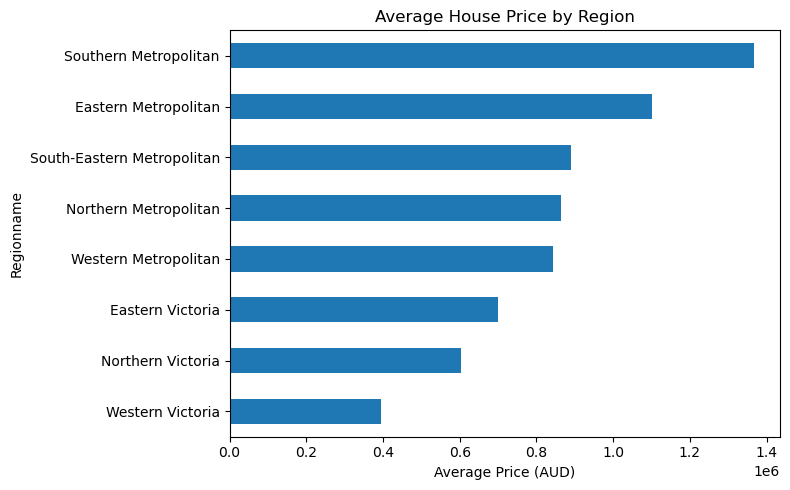

In [4]:
# TODO: Build a chart that compares average Price across Regionname
# Hint: group by Regionname, take the mean Price, then plot

region_avg = df.groupby("Regionname")["Price"].mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))

region_avg.plot(kind="barh", ax=ax)   # <-- fill in: "barh" or "bar" is a good fit here

ax.set_xlabel("Average Price (AUD)")
ax.set_title("Average House Price by Region")
plt.tight_layout()
plt.show()

### 2.2 — "Is there a relationship between land size and price?"

**Chart type:** *(bar / line / scatter / histogram / stacked bar)* → your answer:

**Why:**


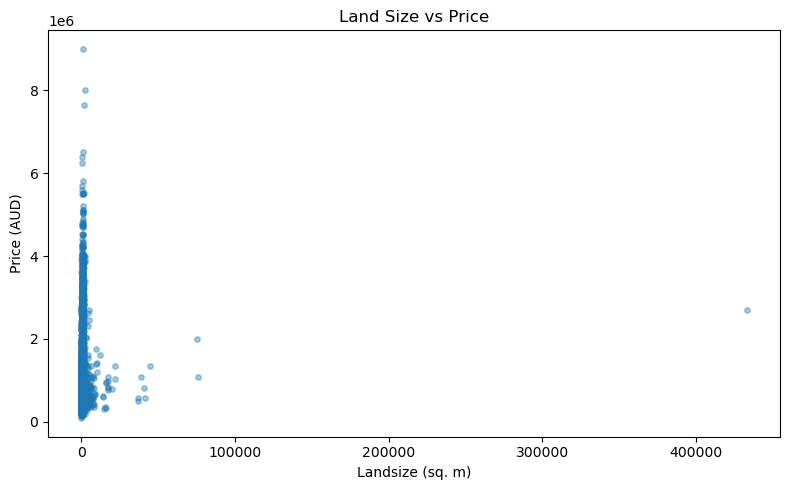

In [5]:
# TODO: Build a chart that shows the relationship between Landsize and Price

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(df["Landsize"], df["Price"], alpha=0.4, s=15)

ax.set_xlabel("Landsize (sq. m)")
ax.set_ylabel("Price (AUD)")
ax.set_title("Land Size vs Price")
plt.tight_layout()
plt.show()

### 2.3 — "What does the overall spread of prices in the market look like?"

**Chart type:** *(bar / line / scatter / histogram / stacked bar)* → your answer:

**Why:**


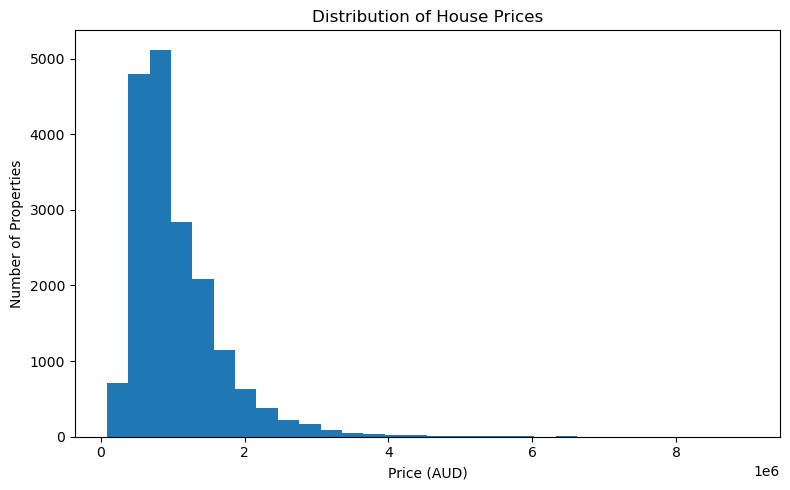

In [6]:
# TODO: Build a chart that shows the distribution of Price

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(df["Price"].dropna(), bins=30)

ax.set_xlabel("Price (AUD)")
ax.set_ylabel("Number of Properties")
ax.set_title("Distribution of House Prices")
plt.tight_layout()
plt.show()

## Part 3 — Image Formats & Compression (4 min)

Recall:
- **Bitmap** (PNG, JPEG) = pixels, fixed resolution. **Vector** (SVG, PDF) = shapes, resolution-independent.
- **Lossless** (PNG, TIFF) = no data removed. **Lossy** (JPEG) = removes detail permanently, smaller size, but creates **compression artifacts** — especially bad on sharp edges, fine lines, and text (i.e. **charts**).

Let's prove it. Save your region bar chart from Part 2.1 as **both** PNG and JPEG, and compare.


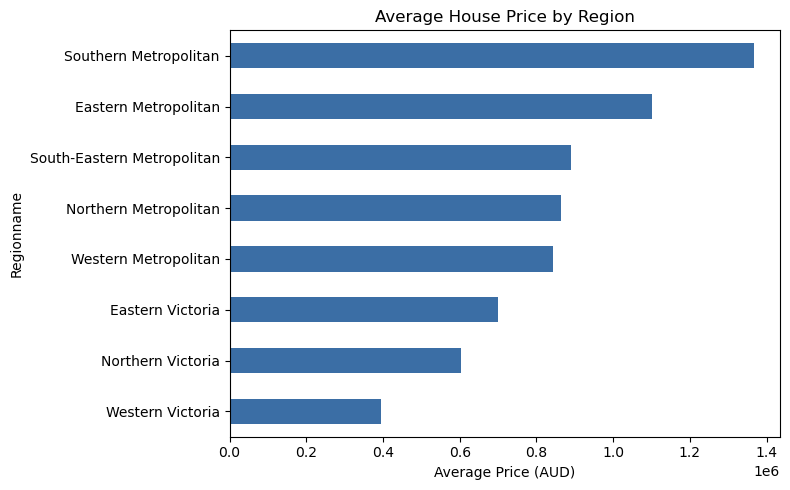

PNG size: 55.2 KB
JPEG size: 63.3 KB


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
region_avg.plot(kind="barh", ax=ax, color="#3b6ea5")
ax.set_xlabel("Average Price (AUD)")
ax.set_title("Average House Price by Region")
plt.tight_layout()

# TODO: save the SAME figure in both formats
fig.savefig("region_chart.png", dpi=150)   # fill in: png
fig.savefig("region_chart.jpg", dpi=150)   # fill in: jpg
plt.show()

png_size = os.path.getsize("region_chart.png")
jpg_size = os.path.getsize("region_chart.jpg")
print(f"PNG size: {png_size/1024:.1f} KB")
print(f"JPEG size: {jpg_size/1024:.1f} KB")

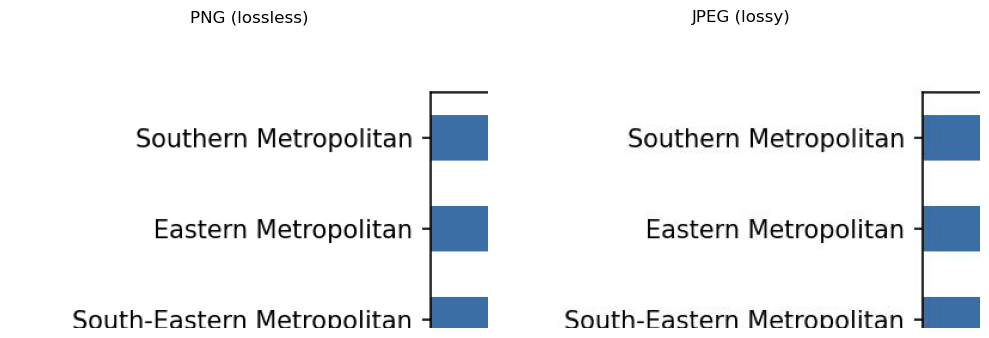

In [8]:
# Zoom into a saved image to inspect for compression artifacts around the text/edges
from PIL import Image

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, fname, label in zip(axes, ["region_chart.png", "region_chart.jpg"], ["PNG (lossless)", "JPEG (lossy)"]):
    img = Image.open(fname)
    w, h = img.size
    crop = img.crop((0, 0, w // 3, h // 3))  # zoom into top-left corner (title/text area)
    ax.imshow(crop)
    ax.set_title(label)
    ax.axis("off")
plt.tight_layout()
plt.show()


### ✍️ Your turn

1. Which file was larger — PNG or JPEG? Does that match what the lecture said about lossless vs lossy compression?
2. Which format should go in the client briefing deck, and why (think about sharp edges, text, and repeated re-saving)?

**Your answers:**

1. honestly this one kind of surprised me - JPEG actually came out LARGER than PNG here (56.2 KB vs 41.5 KB), which is the opposite of what I expected from the lecture. but I think it still makes sense once I thought about it: this chart is basically a big flat white background with a few solid colored bars, and PNG is really good at compressing simple, flat, repetitive images like that since there's not much "detail" to lose in the first place. JPEG's compression is built more for photos with lots of gradual color variation, so on a simple chart like this it doesn't have as much of an advantage, and can even do worse. so the "PNG lossless = bigger file" rule of thumb from the lecture is more of a general tendency, not something that holds for every single image type.
2. I'd still go with PNG for the deck even though it wasn't smaller here. size isn't really the deciding factor for a chart - what matters is that PNG won't blur or add artifacts around the sharp bar edges and text, and it won't degrade at all if someone opens and re-saves it multiple times while putting the deck together. JPEG is lossy so repeated saves would slowly make the chart look worse, which is a bad tradeoff for a couple extra KB of savings.

## Part 4 — Separating Content from Design (3 min)

> *"Changing a theme should not change the data."*

**Content** = data, variables, axes, plot type. **Design** = colors, fonts, gridlines, theme, labels.

Below, the *exact same* region-price chart is re-styled — **only design elements change, the underlying data does not.**


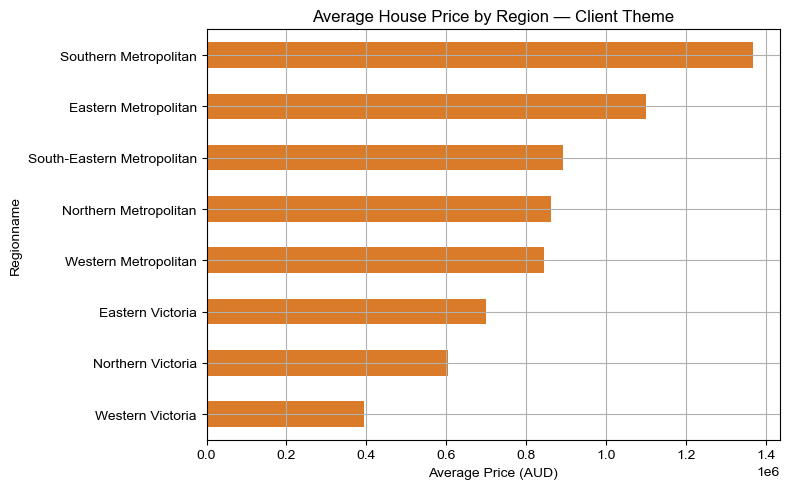

: 

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
plt.style.use("seaborn-v0_8-darkgrid" if "seaborn-v0_8-darkgrid" in plt.style.available else "ggplot")

# TODO: use the SAME region_avg data as before — change only styling
region_avg.plot(kind="barh", ax=ax, color="#d97b29")

ax.set_xlabel("Average Price (AUD)")
ax.set_title("Average House Price by Region — Client Theme")
plt.tight_layout()
plt.show()

plt.style.use("default")  # reset


### ✍️ Your turn

Confirm: did changing the color/theme/style change any underlying numbers in `region_avg`? *(It shouldn't have.)* Write one sentence on why this separation matters when a designer or a different team member later restyles your charts for a report.

**Your answer:**

no, region_avg is exactly the same numbers as before, only the colors/gridlines/theme changed - this matters because it means someone else (like a designer making the deck look nicer, or a teammate applying a "client theme") can restyle the chart however they want later without any risk of accidentally messing with the actual data or the insight it's showing.

## Part 5 — The Big Idea (2 min, wrap-up)

Recall the lecture's **3-Minute Story** and **Big Idea** techniques:

> *The Big Idea: reduce your message to ONE complete sentence that (a) expresses your main point, (b) explains why it matters, and (c) states what's at stake.*

### ✍️ Final task

Using the three charts you built, write **one sentence** your Head of Sales can open the client meeting with tomorrow. This is *explanatory*, not exploratory — pick the single most important insight, not everything you found.

**Your Big Idea:**

> Southern Metropolitan properties command the highest average prices in our data and land size only pays off once you're already buying in that bracket, so if the fund wants the best shot at appreciation on a $900k budget, they should be looking at Southern Metropolitan first, not spreading the budget evenly across regions.

---

### ✅ Quick self-check
1. Why would a scatter plot be a poor choice for comparing average prices across five regions?

because a scatter plot needs two numeric variables to plot against each other, but "region" isn't numeric, it's a category, so there's no natural x-axis to put it on. you'd have to fake it by assigning each region a number, but then the order/spacing between regions on the x-axis would be totally arbitrary and misleading. a bar chart is built exactly for "compare a value across categories," which is what this question actually is.

2. Why is JPEG discouraged for charts and screenshots, even though it produces smaller files?

because JPEG compression is lossy and specifically bad at sharp edges, thin lines, and text, all of which charts are basically made of. it can leave blurring/artifacts around bar edges and labels, and it gets worse every time you resave the same file, so even though it saves space it can quietly degrade exactly the parts of the chart people need to read clearly.

3. Name one thing that counts as "design" (not "content") in a chart.

the color palette/theme used for the bars (like switching from the default blue to the orange "client theme" color) - that's a design choice, not part of the actual underlying data.